In [25]:
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("datasets/powerplant_data.csv")

In [3]:
print(df.columns)
print("AT :- Temperature")
print("V :- Vaccume")
print("AP :- pressure")
print("RH :- humidity")
print("PE :- producesd energy")

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')
AT :- Temperature
V :- Vaccume
AP :- pressure
RH :- humidity
PE :- producesd energy


In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [7]:
#drop Duplicates
df.drop_duplicates(inplace=True)

In [8]:
# train test split

# feature selection
feature = ['AT', 'V', 'AP', 'RH']

x = df[feature]
y = df['PE']


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(df.shape)

(7621, 4)
(1906, 4)
(9527, 5)


In [9]:
# standard Scaling
scale = StandardScaler()

x_train_scaled = pd.DataFrame(scale.fit_transform(x_train),columns=x_train.columns)
x_test_scaled = pd.DataFrame(scale.transform(x_test), columns=x_test.columns)

In [10]:
# converting data into tensors

x_train_tensor = torch.tensor(x_train_scaled.values, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_scaled.values, dtype=torch.float32)
y_train_tensor =  torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor =  torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# why do we have write view in last for y test and train, it's because when currently before writing view
# the shape of y train tensor is 1 d and model requires 2d tensor,  so what view does it convert the 1d in to 2d tensor -1 means row and 1 means columns

In [11]:
type(x_train_tensor)

torch.Tensor

In [12]:
type(x_train)

pandas.core.frame.DataFrame

In [13]:
type(x_train_scaled)

pandas.core.frame.DataFrame

In [14]:
# converting tensors into tensor dataset into dataloader 

# tensor dataset allow us to access the data from our system memory, in other words it defines our dataset 
# dataloader create batches for the NN, size depends on us and we can also shuffle the data and then crat batches

train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [15]:
# build ANN Model 



class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(x_train.shape[1],6),  # in here implement our hidden layer, where we feed the nn.Linear as total number of feature and total number of output
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output Layer
            nn.Linear(6,1),
        )


    def forward(self,x):
        return self.model(x)

In [16]:
import torch.optim as optim

model = ANN()

# loss optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [17]:
# Train the ANN
train_losses = []
valid_losses = []
best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.00
    
    for xb,yb in train_loader:
        # xb = feature of a batch
        # yb = labeled feature of 1 batch
        optimizer.zero_grad()
        output = model(xb)   #forward propogation.... predicted value for each bathc
        loss = criterion(output,yb)    # compute loss
        loss.backward()     # back Propagation, compute gradient 
        optimizer.step() # parameter update

        running_loss += loss.item()  #its calculating loss fo0r 1 batch 
    epoch_train_loss = running_loss / len(train_loader)   #average loss per batch 
    train_losses.append(epoch_train_loss)


        # validation 
    running_Val_loss = 0.00   #running loss for validation testing data
    model.eval()        #this part will cover later
    with torch.no_grad():  # this functuion for to not compute gradient decent we do not need here for testing purpose
        for xb,yb in test_loader:    
            output = model(xb)     # calculating loss
            loss = criterion(output,yb)   #calculatiing loss by Mean Squared error
            running_Val_loss += loss.item()   

    epoch_val_loss = running_Val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & Validation loss {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        epoch_val_loss = best_val_loss
        torch.save(model.state_dict(), "best_power_model.pt")

epoch 1/100 ==> train loss = 205764.68226987447 & Validation loss 203698.57760416667
epoch 2/100 ==> train loss = 195585.07289487447 & Validation loss 182938.1625
epoch 3/100 ==> train loss = 161984.16628530333 & Validation loss 136557.60260416666
epoch 4/100 ==> train loss = 108945.4229537134 & Validation loss 80135.92154947917
epoch 5/100 ==> train loss = 59278.95133531642 & Validation loss 40711.414453125
epoch 6/100 ==> train loss = 32548.516172528765 & Validation loss 25597.315071614583
epoch 7/100 ==> train loss = 23457.701437467313 & Validation loss 20647.770426432293
epoch 8/100 ==> train loss = 19448.72352248954 & Validation loss 17414.73533528646
epoch 9/100 ==> train loss = 16209.62347999477 & Validation loss 14341.143473307291
epoch 10/100 ==> train loss = 13068.065511408211 & Validation loss 11351.617887369792
epoch 11/100 ==> train loss = 10069.583447061323 & Validation loss 8534.950927734375
epoch 12/100 ==> train loss = 7348.061377361729 & Validation loss 6027.338956705

<Axes: xlabel='train_losses', ylabel='valid_losses'>

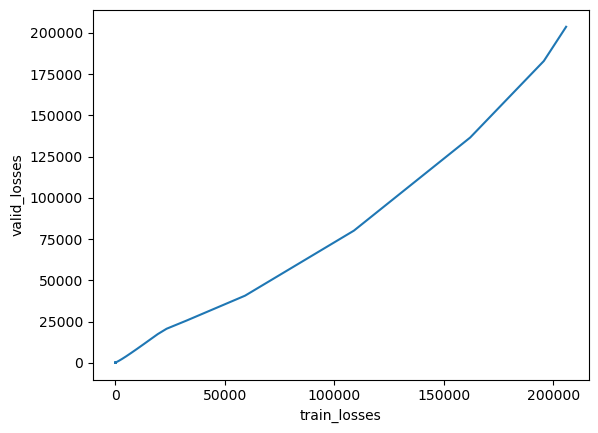

In [18]:
df1 = pd.DataFrame({"train_losses":train_losses,"valid_losses":valid_losses})




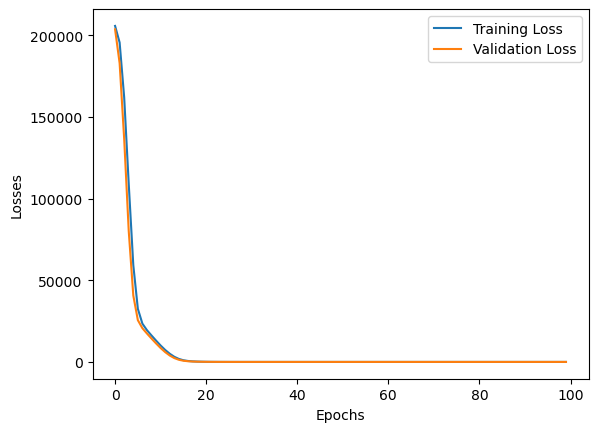

In [19]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [28]:
# model evaluation


with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)
    
    train_MSE_loss = criterion(train_preds,y_train_tensor)
    test_MSE_loss = criterion(test_preds,y_test_tensor)


print("Training MSE",train_MSE_loss.item())
print("Testing MSE",test_MSE_loss.item())


print("R^2 Score on Tr=esting",r2_score(y_test_tensor,test_preds))
print("R^2 Score on Training",r2_score(y_train_tensor,train_preds))


Training MSE 20.44609260559082
Testing MSE 20.63593101501465
R^2 Score on Tr=esting 0.9316214919090271
R^2 Score on Training 0.928864598274231


In [34]:
Predicted_Values = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_Values = pd.DataFrame(y_test.values, columns=["Actual Values"])
pd.concat([Predicted_Values,actual_Values], axis=1)


,Predicted Values,Actual Values
0,427.136108,429.38
1,480.648926,485.29
2,482.131653,480.40
3,450.186646,452.30
4,447.544983,446.47
...,...,...
1901,486.534821,490.50
1902,445.326050,443.31
1903,436.531555,441.14
1904,429.392883,438.47
